Exam score prediction

In [399]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import linear_model, metrics, svm, ensemble
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [400]:
df = pd.read_csv("exams.csv")
df.head(100)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68
...,...,...,...,...,...,...,...,...
95,female,group C,high school,standard,completed,58,63,67
96,female,group E,associate's degree,standard,completed,95,100,100
97,male,group B,high school,free/reduced,none,45,52,49
98,male,group A,some college,standard,none,63,50,49


In [401]:
# Deleting not usefull data
df = df.drop('race/ethnicity', axis=1)

In [402]:
educationLvl = df
educationLvl = educationLvl.drop('lunch', axis=1)
educationLvl = educationLvl.drop('gender', axis=1)
educationLvl = educationLvl.drop('test preparation course', axis=1)
educationLvl = educationLvl.groupby("parental level of education").mean()
educationLvl.head(50)

,math score,reading score,writing score
parental level of education,,,
associate's degree,69.536946,70.985222,70.113300
bachelor's degree,71.491071,74.008929,74.410714
high school,65.207921,67.400990,64.846535
master's degree,71.585714,75.428571,75.885714
some college,65.297297,68.045045,66.734234
some high school,60.701571,64.408377,62.539267


In [403]:
df["associate's degree"] = 0
df["bachelor's degree"] = 0
df["high school"] = 0
df["master's degree"] = 0
df["some college"] = 0
df["some high school"] = 0

In [404]:
lunch = df[["lunch"]]
lunch = lunch.groupby("lunch").mean()
lunch

""
lunch
free/reduced
standard


In [405]:
df["had lunch"] = 0

In [406]:
test_prep = df[["test preparation course"]]
test_prep = test_prep.groupby("test preparation course").mean()
test_prep

""
test preparation course
completed
none


In [407]:
df["completed preparation course"] = 0

In [408]:
df["male"] = 0
df["female"] = 0

In [409]:
# one-hot encoding for genders
genders = [
    "male",
    "female",
]
for gend in genders:
    df[gend] = (df["gender"] == gend).astype(int)
df = df.drop("gender", axis=1)

In [410]:
# binary encoding for those who finished course
df["completed preparation course"] = (df["test preparation course"] == "completed").astype(int)
df = df.drop("test preparation course", axis=1)

# binary encoding for those who ate lunch
df["had lunch"] = (df["lunch"] == "standard").astype(int)
df = df.drop("lunch", axis=1)

In [411]:
# one-hot encoding for parental level of education
levels = [
    "associate's degree",
    "bachelor's degree",
    "high school",
    "master's degree",
    "some college",
    "some high school",
]

for lvl in levels:
    df[lvl] = (df["parental level of education"] == lvl).astype(int)
df = df.drop("parental level of education", axis=1)

In [412]:
# average score of 3 exams
df["avg score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

In [413]:
# passed exam if scores of all exams are higher than 60
df['passed exam'] = ((df['math score'] > 60) & 
                     (df['reading score'] > 60) & 
                     (df['writing score'] > 60)).astype(int)

<Axes: >

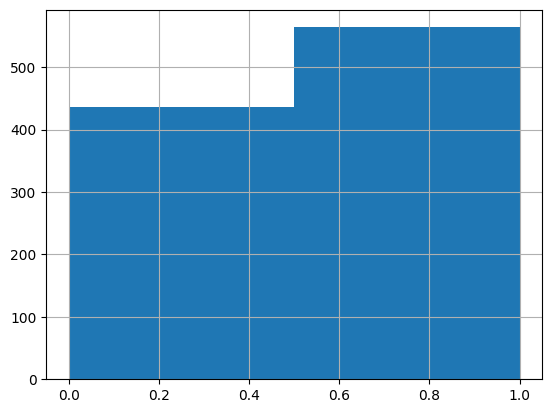

In [414]:
# distribution of "passed exam"
df['passed exam'].hist(bins=2) 

<Axes: >

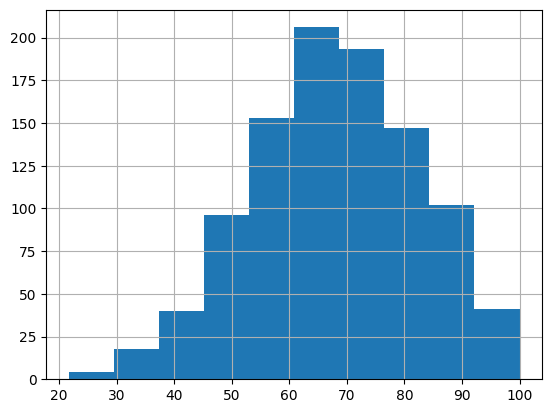

In [415]:
# distribution of "avg score"
df['avg score'].hist(bins=10) 

<Axes: >

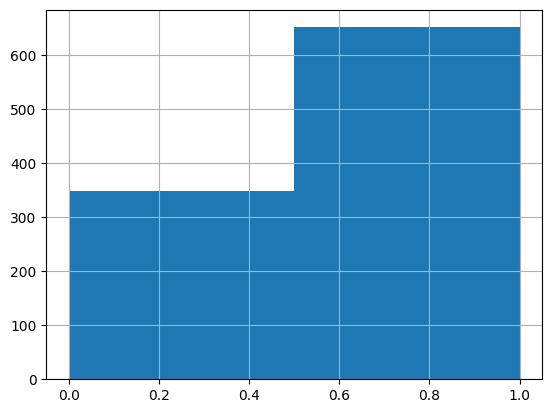

In [416]:
# distribution of "had lunch"
df['had lunch'].hist(bins=2) 

<Axes: >

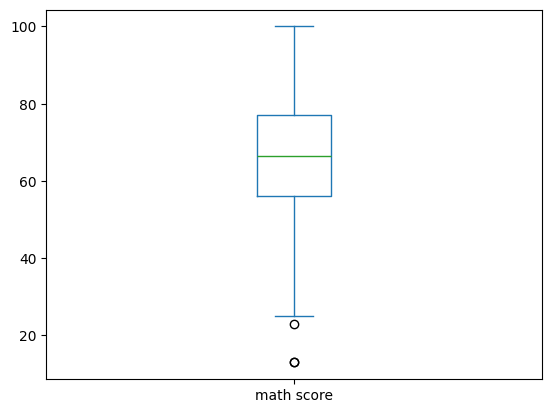

In [417]:
# distribution of scores
df['math score'].plot.box() 

<Axes: >

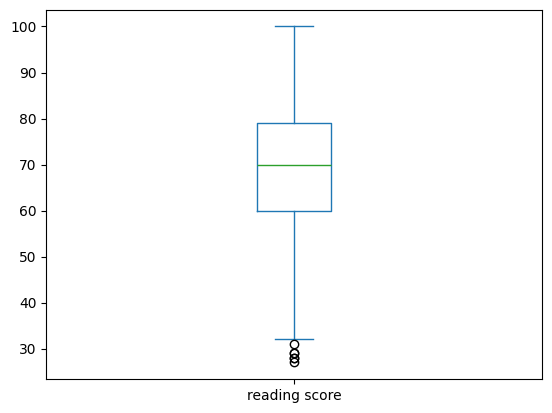

In [418]:
df['reading score'].plot.box() 

<Axes: >

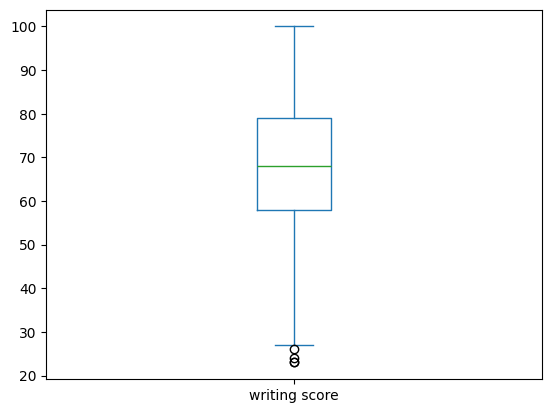

In [419]:
df['writing score'].plot.box() 

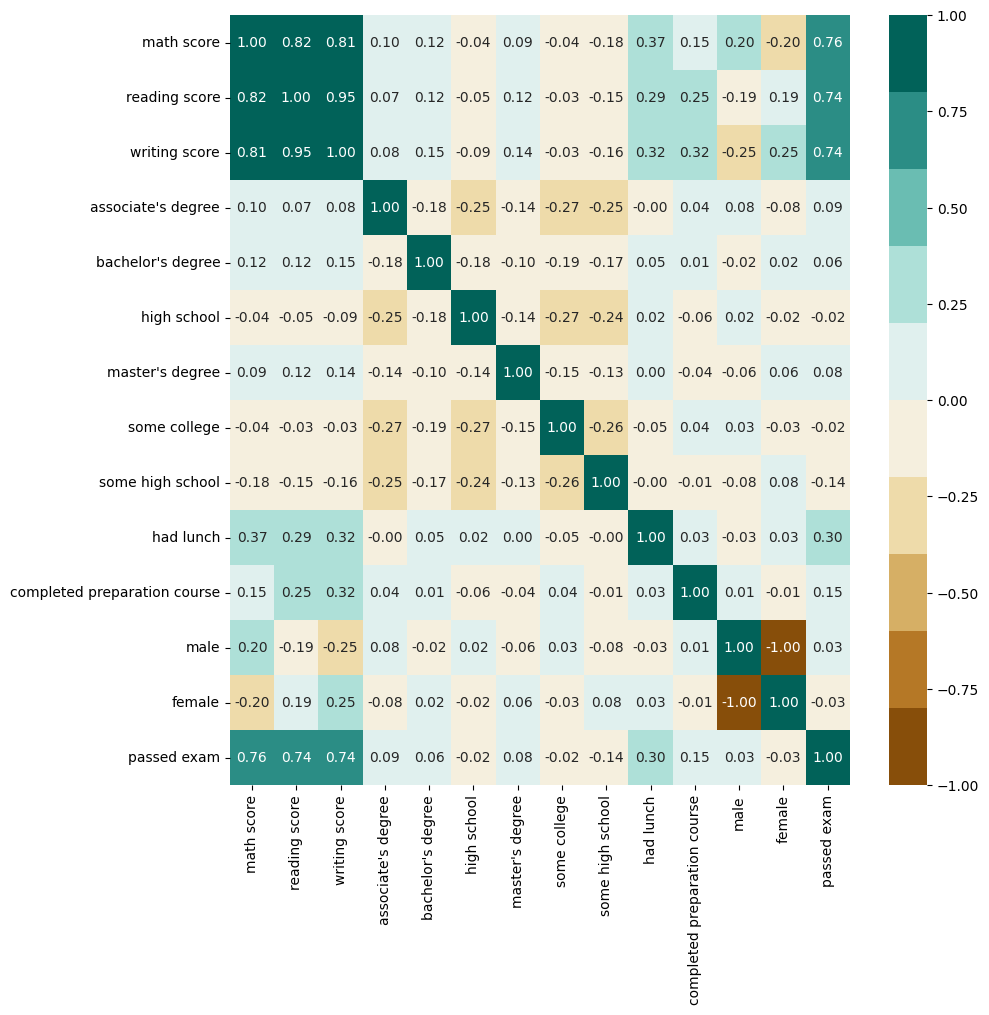

In [420]:
# Display correlation matrix
matrix = df.drop("avg score", axis=1)
correlations = matrix.corr()
fig, ax = plt.subplots(figsize=(10, 10))

colormap = sns.color_palette("BrBG", 10)

sns.heatmap(correlations, cmap=colormap, annot=True, fmt=".2f")

plt.show()

In [421]:
# create training set
categories = [
    "associate's degree", "bachelor's degree", "high school", "master's degree",
    "some college", "some high school", "had lunch", "completed preparation course",
    "male", "female"
]
X = df[categories]
X

,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,had lunch,completed preparation course,male,female
0,0,0,1,0,0,0,1,1,1,0
1,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,1,0,0,0,1,0
3,0,0,1,0,0,0,1,0,1,0
4,1,0,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...
995,0,0,1,0,0,0,1,0,1,0
996,1,0,0,0,0,0,0,1,1,0
997,0,0,0,0,0,1,0,0,0,1
998,0,0,0,0,1,0,1,0,0,1


In [422]:
# create labels for training set
#y = df.loc[:, 'passed exam'].to_numpy()
y = df["passed exam"].to_numpy()
y

array([1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [423]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345, stratify=y,)

In [424]:
# universal method for training and evaluation of models

def train_model(classifier, feature_vector_train, label, feature_vector_valid):
    # train model
    classifier.fit(feature_vector_train, label)
    # universal method for training and evaluation of models

def train_model(classifier, feature_vector_train, label, feature_vector_valid):
    # train model
    classifier.fit(feature_vector_train, label)

    # generate labels for validation set
    predictions = classifier.predict(feature_vector_valid)

    # evealuate model based on test set labels
    scores = list(metrics.precision_recall_fscore_support(predictions, y_test))
    score_vals = [
        scores[0][0],
        scores[1][0],
        scores[2][0]
    ]
    score_vals.append(metrics.accuracy_score(predictions, y_test))
    return score_vals
    # generate labels for validation set
    predictions = classifier.predict(feature_vector_valid)

    # evealuate model based on test set labels
    scores = list(metrics.precision_recall_fscore_support(predictions, y_test))
    score_vals = [
        scores[0][0],
        scores[1][0],
        scores[2][0]
    ]
    score_vals.append(metrics.accuracy_score(predictions, y_test))
    return score_vals

In [425]:
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(436), np.int64(1): np.int64(564)}


In [462]:
# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
accuracy_lr = accuracy_score(y_test, lr_pipeline.predict(X_test))
print("LR Accuracy:", accuracy_lr)

# SVM pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", svm.SVC(class_weight="balanced", probability=True)) 
])
svm_pipeline.fit(X_train, y_train)
accuracy_svm = accuracy_score(y_test, svm_pipeline.predict(X_test))
print("SVM Accuracy:", accuracy_svm)

rf = RandomForestClassifier(
    n_estimators=200, 
    random_state=13579,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
accuracy_rf = accuracy_score(y_train, y_train)
print("Random Forest Test Accuracy:", accuracy_rf)
df["passed exam"].value_counts(normalize=True)

LR Accuracy: 0.725
SVM Accuracy: 0.735
Random Forest Test Accuracy: 1.0


passed exam
1    0.564
0    0.436
Name: proportion, dtype: float64

In [464]:
data = pd.DataFrame({
    "associate's degree": [0],
    "bachelor's degree": [0],
    "high school": [0],
    "master's degree": [1],
    "some college": [0],
    "some high school": [0],
    "had lunch": [0],
    "completed preparation course": [0],
    "male": [0],
    "female": [1]
})

#  probability of passing all exams
# logistic regression
prob_lr = lr_pipeline.predict_proba(data)[:,1][0]  # tylko klasa 1
print("LR predicts probability of passing exams:", round(prob_lr*100,2), "%")

# svm 
prob_svm = svm_pipeline.predict_proba(data)[:,1][0]
print("SVM predicts probability of passing exams:", round(prob_svm*100,2), "%")

#rf
prob_rf = rf.predict_proba(data)[:,1][0]
print("Random forest predicts probability of passing exams:", round(prob_rf*100,2), "%")

LR predicts probability of passing exams: 47.63 %
SVM predicts probability of passing exams: 53.93 %
Random forest predicts probability of passing exams: 44.74 %
